This experiment verifies the distribution of message recipients for dragonfly topology 

# 0. User Parameters, Imports, Environment

## User Parameters

In [1]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_hotspot_verification'

# Configuration parameters
node_counts = [1,2]
groups_per_node = 1 # Total groups will scale with the number of nodes
routers_per_group = 32 
hosts_per_router = 16

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 1

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

workflow_dir: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


## Calculated 'Constants'

In [2]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

'/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif'

## Imports

In [3]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [4]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [5]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif already exists.


## Prepare the e4s-cl profile

In [6]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.py


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.py already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.so


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.so already in profile's files


> e4s-cl profile edit --image /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif


## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [7]:
check_mpi_binding(sst_container_dest_path)

e4s-cl profile : sst-experiments
profile image  : /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif
container SST  : /opt/SST/16.0.0/libexec/sstsim.x
container MPI  : libmpi.so.12
bound host MPI : libmpi_cray.so.12 -> /opt/cray/pe/lib64/libmpi_cray.so.12
bound host PMI : libpals.so.0, libpmi.so.0, libpmi2.so.0
OK: e4s-cl will inject a host MPI into the container.


True

# 2. Build Benchmarks

In [8]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make clean', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make clean']


rm -rf libmerlin_benchmark.so
rm -f /lus/bnchlu1/neth/mysst/sst-elements/install/lib/sst-elements-library/libmerlin_benchmark.so
	Model merlin_benchmark has been unregistered!
rm -f *.json *.tmp *.time *.out *.csv
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make -j10']


	Error removing /home/users/neth/.sst/sstsimulator.conf before moving updated config


g++ -std=c++17  -std=c++17 -fexcess-precision=fast -fPIC -DHAVE_CONFIG_H -I/opt/SST/16.0.0/include -g -shared -fno-common -Wl,-undefined -Wl,dynamic_lookup "-DENABLE_SSTCHECKPOINT" -o libmerlin_benchmark.so src/trafficgen.cc
/opt/SST/16.0.0/bin//sst-register merlin_benchmark merlin_benchmark_LIBDIR=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark


# 3. Generate Argument Tuples

In [9]:
run_specs = []
for node_count in node_counts:
    num_groups = groups_per_node * node_count
    run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = (node_count,),
        topologies=('dragonfly',),
        global_params={'stop_at': (100),
                       'verbose': 5},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,),
        },
        endpoint_params={
            'tg_packet_dest_pattern': 'HotSpot',
            'tg_packet_dest_hotspot_target': 0,
            'tg_packet_dest_hotspot_target_probability': 0.1
        },
        experiment_name=experiment_name)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

Generated 2 run specifications.
Example spec:  MerlinRunSpec(run_id='92afc0bf59', run_name='dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1', launcher={'srun': ['--nodes=1', '--ntasks-per-node=1'], 'mpirun': ['-n', '1', '-N', '1']}, sst_args=['--timing-info=3', '--parallel-load=SINGLE'], config_args=['--dragonfly-adaptive-threshold', '2.0', '--dragonfly-algorithm', 'minimal', '--dragonfly-global-routing-mode', 'absolute', '--dragonfly-hosts-per-router', '16', '--dragonfly-intergroup-links', '1', '--dragonfly-num-groups', '1', '--dragonfly-routers-per-group', '32', '--flit-size-bytes', '8', '--link-bw-gbps', '4', '--link-lat-ns', '1', '--stop-at', '100ns', '--tg-input-buf-size', '4kB', '--tg-input-latency', '20ns', '--tg-output-buf-size', '4kB', '--tg-output-latency', '20ns', '--tg-packet-dest-hotspot-target', '0', '--tg-packet-dest-hotspot-target-probability', '0.1', '--tg-packet-dest-pattern', 'HotSpot', '--topology', 'dragonfly', '--verbose', '5', '--xbar-bw-gbps', '4'],

# 4. Launch Runs

In [10]:
launch_jobs(run_specs, workflow_dir, output_dir, sst_input_config, experiment_name, FORCED=FORCED)

> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1
> sbatch --job-name=dragonfly_hotspot_verification --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1/sbatch.err --nodes=1 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1/run.sbatch
Submitted batch job 1642075
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n2_r1_84816d2eea_t1
> sbatch --job-name=dragonfly_hotspot_verific

# 5. Wait for Job Completion

In [11]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 2


Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Queue length: 1


# 6. Collect Simulation Results

In [12]:
log_files = glob.glob(f'{output_dir}/**/run.log', recursive=True)
    
print(log_files)
columns = []
for log_file in log_files:
    msgs = []
    with open(log_file, 'r') as f:
        for line in f:
            if line.startswith('CHECK'):
                #CHECK 1000: Node 154 sending packet to 519 of size 64 bits.
                tokens = line.split()
                # Example tokens: ['CHECK', '1000:', 'Node', '154', 'sending', 'packet', 'to', '519', 'of', 'size', '64', 'bits.']
                if len(tokens) < 11:
                    continue
                msgs.append({
                    'file' : log_file,
                    'timestamp': tokens[1].rstrip(':'),
                    'src_node': tokens[3],
                    'dst_node': tokens[7],
                    'type': tokens[4]
                })
    columns.extend(msgs)

df = pd.DataFrame(columns)

df.to_csv(experiment_result_file, index=False)


['/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n2_r1_84816d2eea_t1/run.log', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_hotspot_verification_out/dragonfly_hotspot_verification_dragonfly_n1_r1_92afc0bf59_t1/run.log']


# 7. Analyze Results

In [13]:
df = pd.read_csv(experiment_result_file)
#df['file'] = df['file'].str.split('/').str[-2].str.split('_').str[-3]
df.head()

# Bin the src_node and dst_node in groups of hosts_per_router
df['src_node_group'] = df['src_node'] // hosts_per_router
df['dst_node_group'] = df['dst_node'] // hosts_per_router

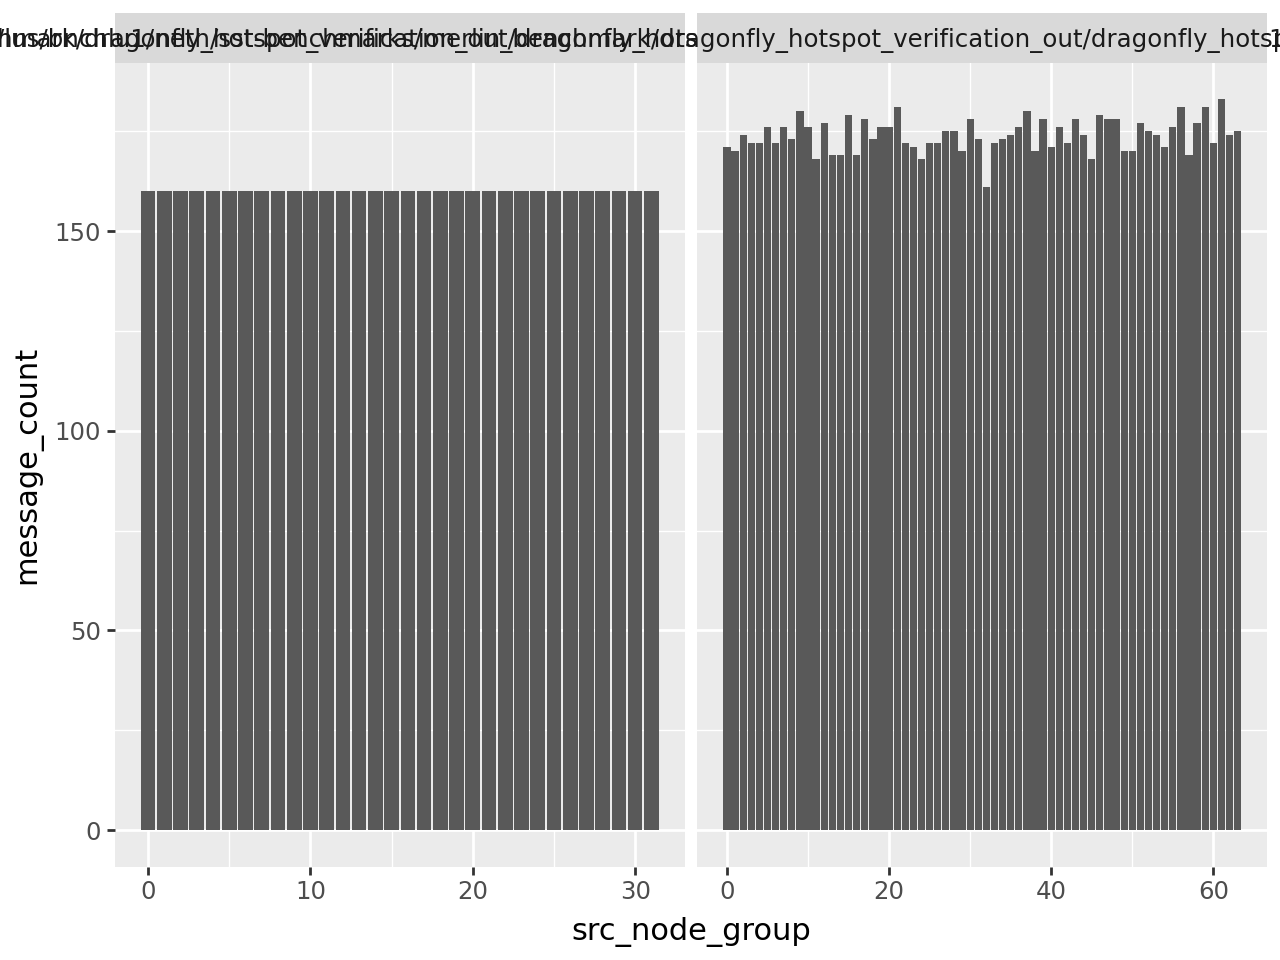

In [14]:
gb = df[df['type'] == 'sending'].groupby(['file', 'src_node_group']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='src_node_group', y='message_count'), stat='identity')
p += facet_wrap('~file', scales='free_x')
p

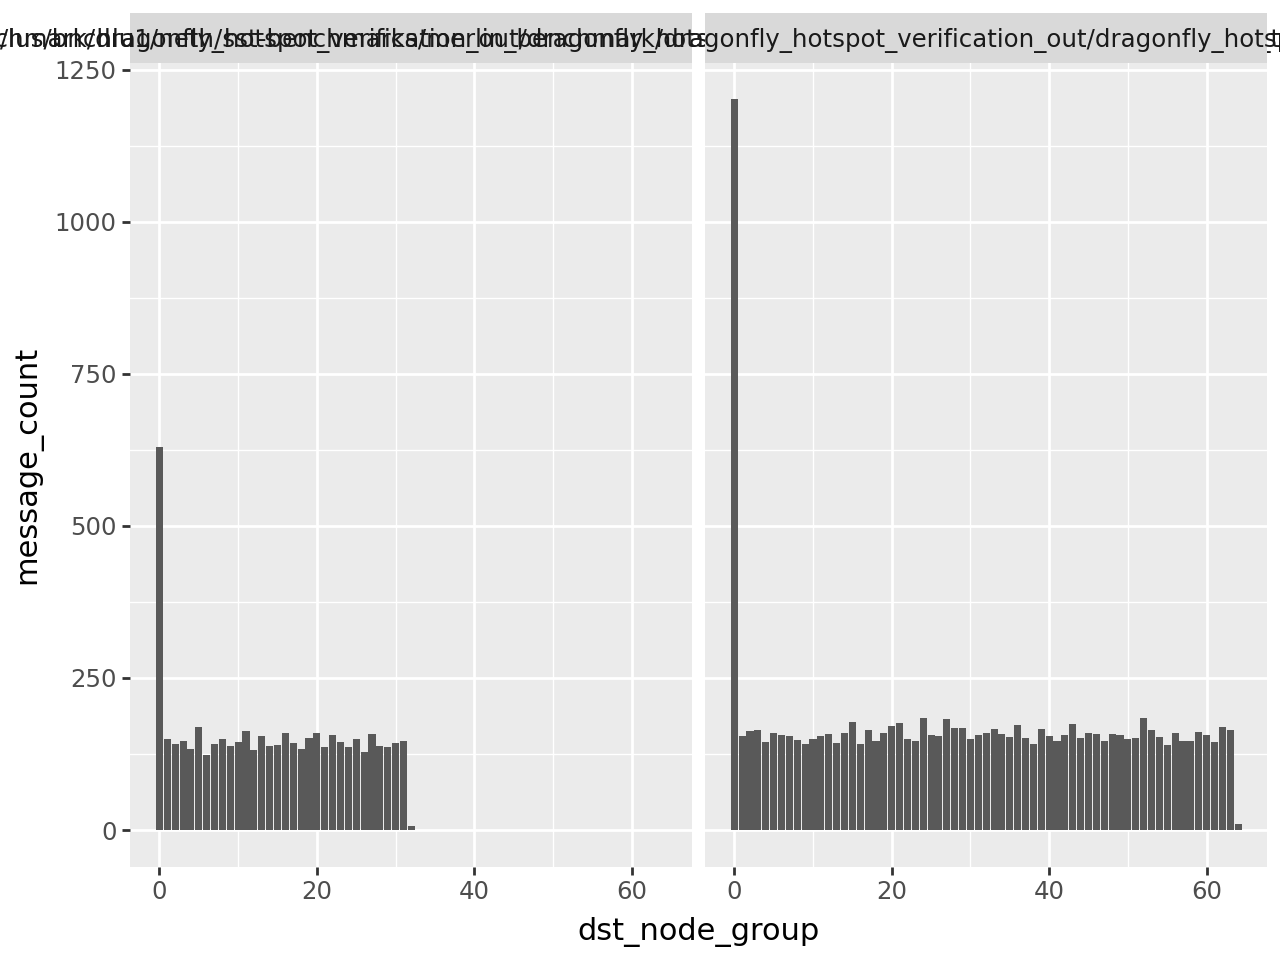

In [15]:
gb = df[df['type'] == 'sending'].groupby(['file', 'dst_node_group']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='dst_node_group', y='message_count'), stat='identity')
p += facet_wrap('~file')
p

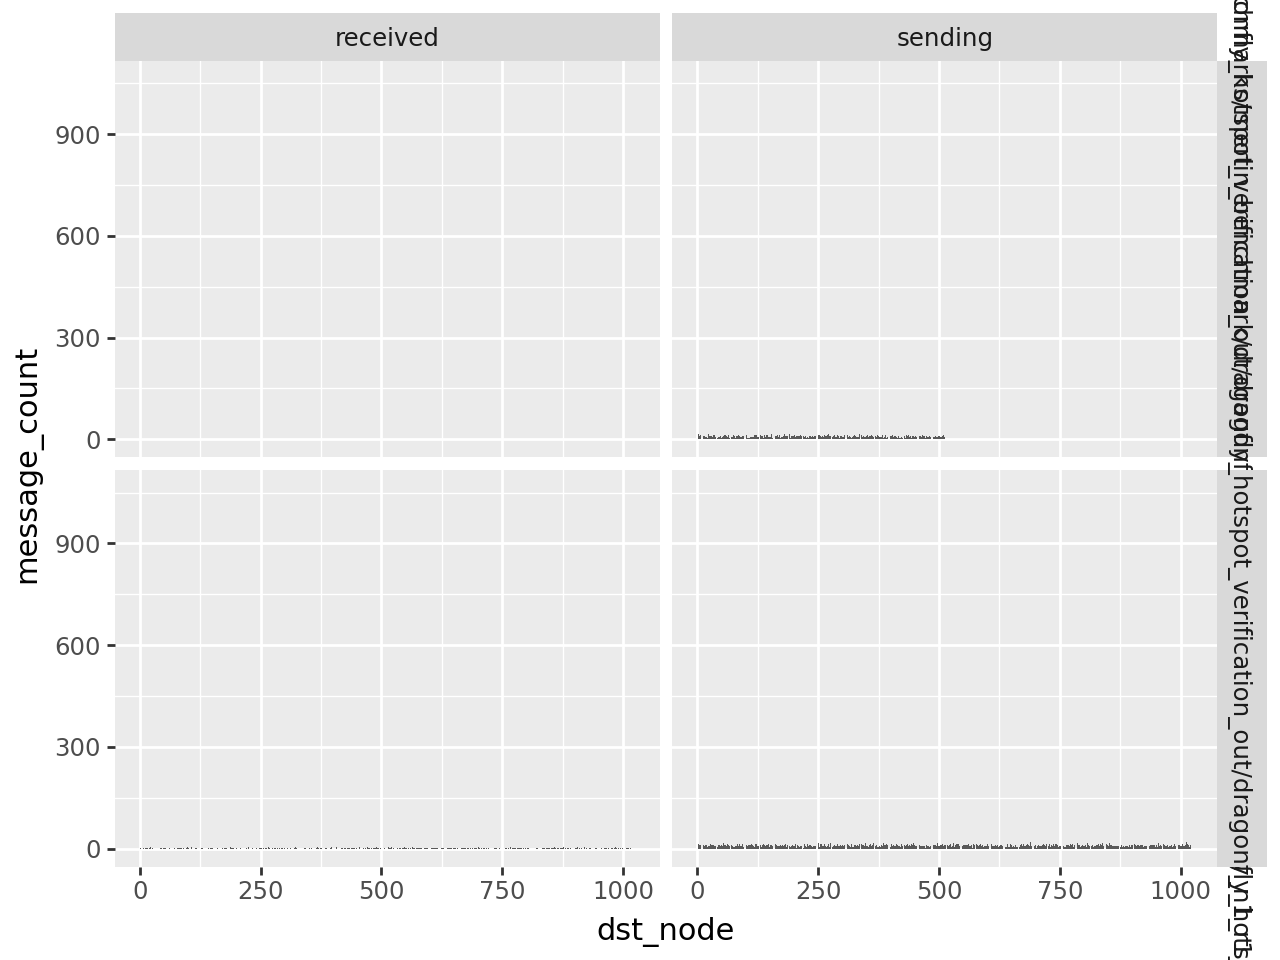

In [16]:
gb = df.groupby(['type', 'file', 'dst_node']).size()
counts_df = gb.reset_index(name='message_count')
counts_df
p = ggplot(counts_df)
p += geom_bar(aes(x='dst_node', y='message_count'), stat='identity')
p += facet_grid('file~type')
p

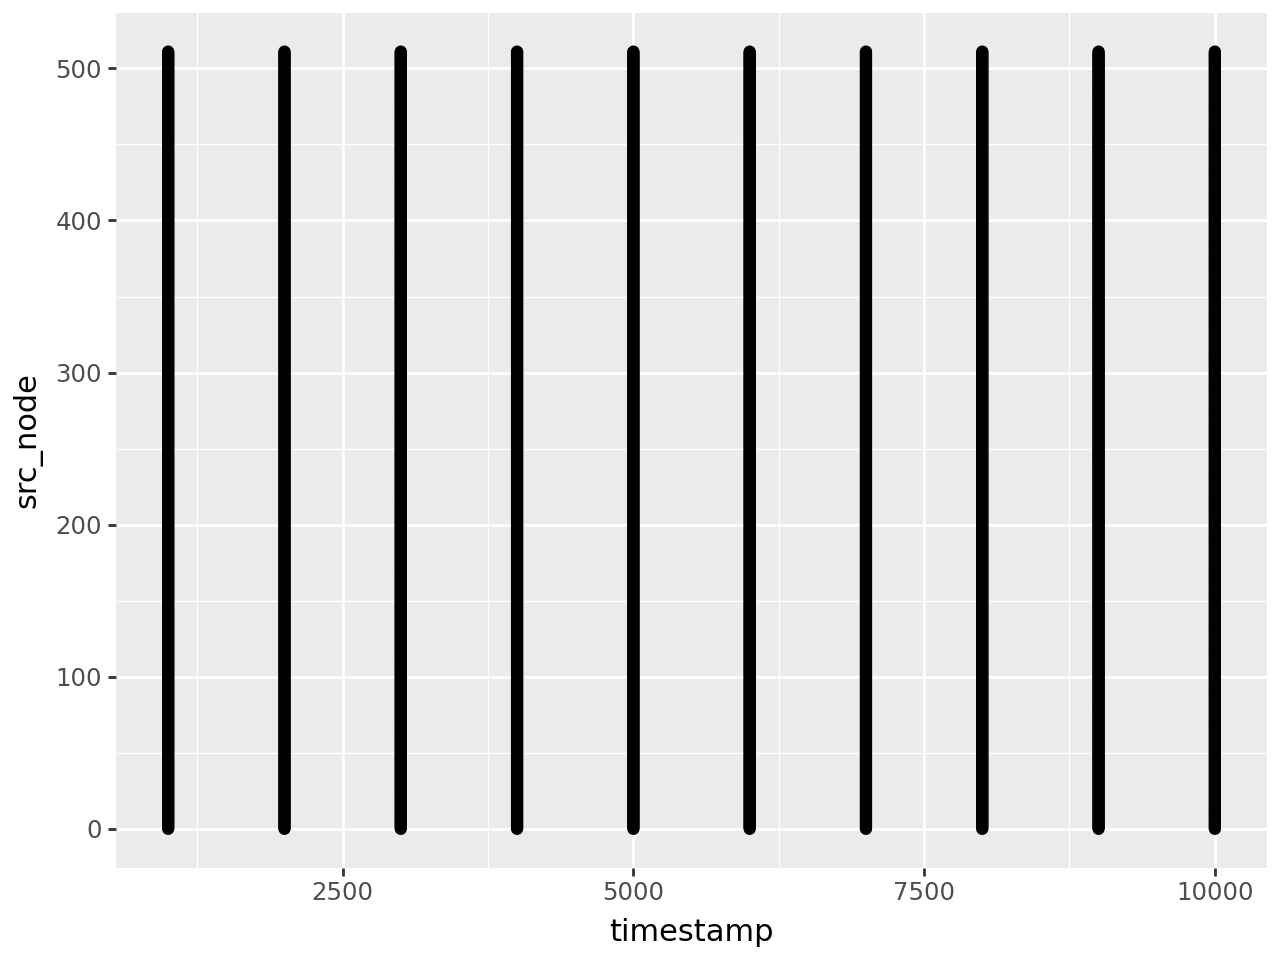

In [17]:
gb = df[df['type'] == 'sending' ].groupby(['timestamp', 'file', 'src_node']).size()
gb_df = gb.reset_index(name='count')
gb_df = gb_df[gb_df['file'].str.contains('n1')]
gb_df
p = ggplot(gb_df, aes(x='timestamp', y='src_node'))
p += geom_point()
p


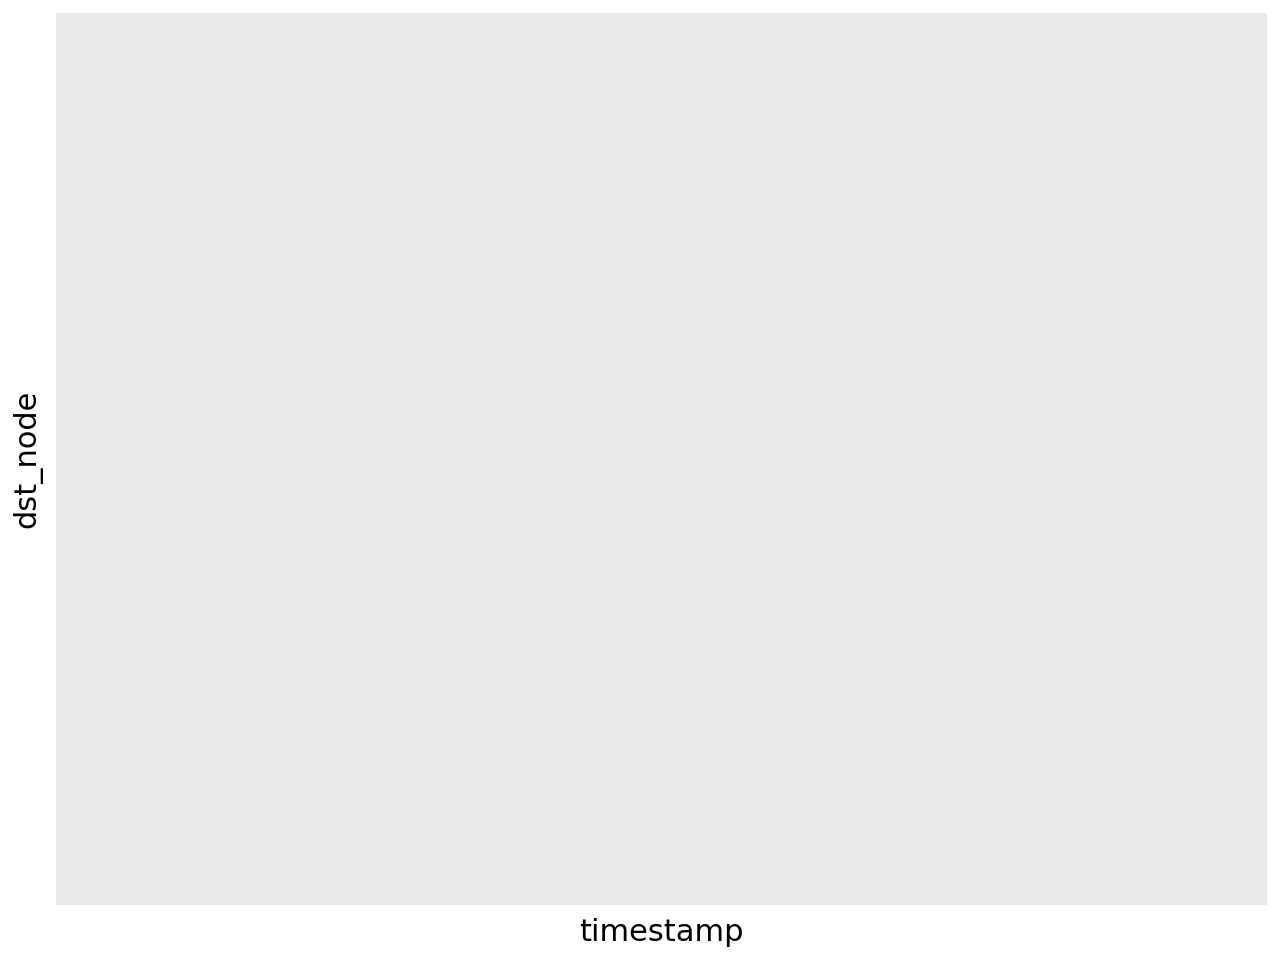

In [18]:
gb = df[df['type'] == 'sending' ].groupby(['timestamp', 'file', 'dst_node']).size()
gb_df = gb.reset_index(name='count')
gb_df = gb_df[gb_df['file'] == 'n1']
gb_df
p = ggplot(gb_df, aes(x='timestamp', y='dst_node', size='count'))
p += geom_point()
p

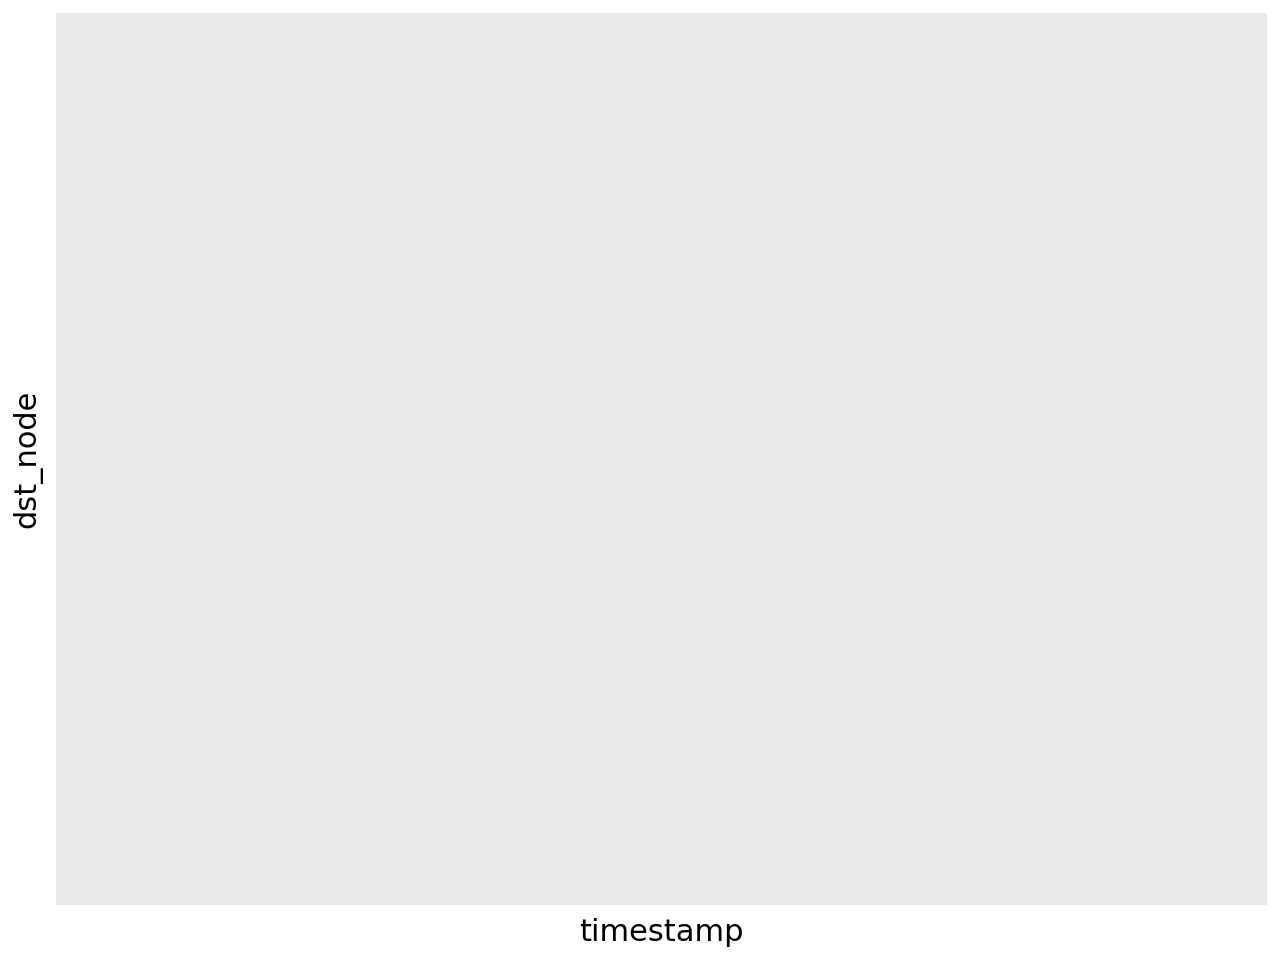

In [19]:
tmp = df[df['file'] == 'n1']

p = ggplot(tmp, aes(x='timestamp'))
p += geom_point(aes(y='dst_node'), alpha=0.5, fill='blue', color='blue')
p += geom_point(aes(y='src_node'), alpha=0.5, fill='red', color='red')
p